In [1]:
import torch
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.models import resnet50

# Step 1: Define data paths
train_data_resnet = "C:/Users/Srikanth/Desktop/DA Assignments/Desertation/Model/Dataset/dataset_resnet/train"
val_data_resnet = "C:/Users/Srikanth/Desktop/DA Assignments/Desertation/Model/Dataset/dataset_resnet/val"

# Step 2: Define transformations for images
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize images to 224x224 (ResNet input size)
    transforms.ToTensor(),          # Convert images to tensors
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # Normalize (ImageNet mean & std)
])

# Step 3: Load datasets
train_dataset = datasets.ImageFolder(root=train_data_resnet, transform=transform)
val_dataset = datasets.ImageFolder(root=val_data_resnet, transform=transform)

# Step 4: Create DataLoaders
batch_size = 32  # Set batch size
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Step 5: Load pre-trained ResNet-50 model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = resnet50(pretrained=True)

# Step 6: Modify the last layer for binary classification (Normal vs. Infected)
num_features = model.fc.in_features  # Get input features of the final layer
model.fc = nn.Linear(num_features, 2)  # Change output layer to 2 classes

model = model.to(device)  # Move model to GPU if available

# Step 7: Define loss function and optimizer
criterion = nn.CrossEntropyLoss()  # Loss function for classification
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Adam optimizer

# Step 8: Training loop
num_epochs = 10  # Set number of epochs

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()  # Clear gradients
        outputs = model(images)  # Forward pass
        loss = criterion(outputs, labels)  # Compute loss
        loss.backward()  # Backpropagation
        optimizer.step()  # Update weights

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = 100 * correct / total
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}, Accuracy: {train_acc:.2f}%")

# Save the trained model
torch.save(model.state_dict(), "resnet50_binary_classification.pth")
print("Model training complete and saved!")



C:\Users\Srikanth\AppData\Roaming\Python\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Srikanth\AppData\Roaming\Python\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\Srikanth/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth
100%|█████████████████████████████████████████████████████████████████████████████| 97.8M/97.8M [00:01<00:00, 77.1MB/s]


Epoch [1/10], Loss: 0.2959, Accuracy: 83.56%
Epoch [2/10], Loss: 0.2032, Accuracy: 94.30%
Epoch [3/10], Loss: 0.1465, Accuracy: 94.97%
Epoch [4/10], Loss: 0.1282, Accuracy: 95.30%
Epoch [5/10], Loss: 0.0847, Accuracy: 96.31%
Epoch [6/10], Loss: 0.0682, Accuracy: 98.32%
Epoch [7/10], Loss: 0.0484, Accuracy: 98.32%
Epoch [8/10], Loss: 0.0611, Accuracy: 96.98%
Epoch [9/10], Loss: 0.1160, Accuracy: 95.64%
Epoch [10/10], Loss: 0.2236, Accuracy: 90.60%
Model training complete and saved!


# ResNet - 50

C:\Users\Srikanth\AppData\Roaming\Python\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Srikanth\AppData\Roaming\Python\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\Srikanth\AppData\Local\Temp\ipykernel_29672\2165645718.py:40: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See htt

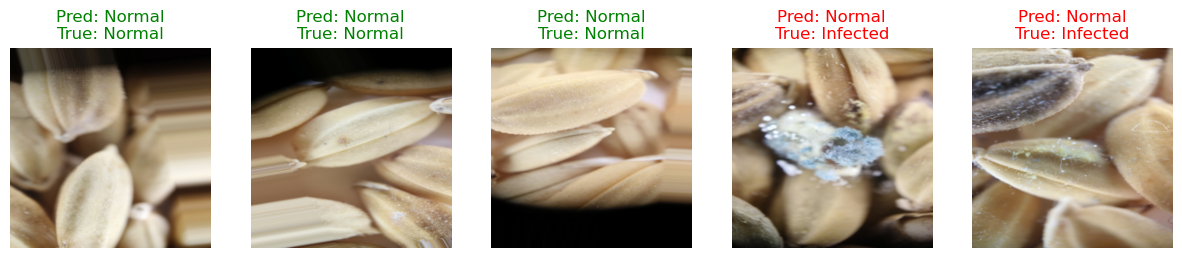

In [7]:
import torch
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from torchvision.models import resnet50
from torch.utils.data import DataLoader
from PIL import Image

# Step 1: Define Paths
train_data_resnet = "C:/Users/Srikanth/Desktop/DA Assignments/Desertation/Model/Dataset/dataset_resnet/train"
val_data_resnet = "C:/Users/Srikanth/Desktop/DA Assignments/Desertation/Model/Dataset/dataset_resnet/val"
test_data_resnet = "C:/Users/Srikanth/Desktop/DA Assignments/Desertation/Model/Dataset/dataset_resnet/test"  # Add test folder

# Step 2: Define Transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Step 3: Load Datasets
train_dataset = datasets.ImageFolder(root=train_data_resnet, transform=transform)
val_dataset = datasets.ImageFolder(root=val_data_resnet, transform=transform)
test_dataset = datasets.ImageFolder(root=test_data_resnet, transform=transform)

# Step 4: Create DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=True)  # Batch size 1 for visualization

# Step 5: Load Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = resnet50(pretrained=True)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)  # Binary Classification (Normal vs. Infected)
model.load_state_dict(torch.load("resnet50_binary_classification.pth"))  # Load trained model
model = model.to(device)
model.eval()  # Set model to evaluation mode

# Step 6: Define Class Names
class_names = test_dataset.classes  # ['Normal', 'Infected']

# Step 7: Test and Display Results
def visualize_predictions(model, test_loader, num_images=5):
    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))

    for i, (image, label) in enumerate(test_loader):
        if i >= num_images:
            break

        image = image.to(device)
        output = model(image)
        _, pred = torch.max(output, 1)  # Get predicted class index
        pred_label = class_names[pred.item()]
        true_label = class_names[label.item()]

        # Convert image tensor to numpy for displaying
        img = image.cpu().squeeze(0).permute(1, 2, 0).numpy()
        img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])  # Unnormalize
        img = np.clip(img, 0, 1)  # Clip to valid range

        # Display image with predicted label
        axes[i].imshow(img)
        axes[i].set_title(f"Pred: {pred_label}\nTrue: {true_label}", color="green" if pred_label == true_label else "red")
        axes[i].axis("off")

    plt.show()

# Step 8: Call the Function to Show Results
visualize_predictions(model, test_loader, num_images=5)


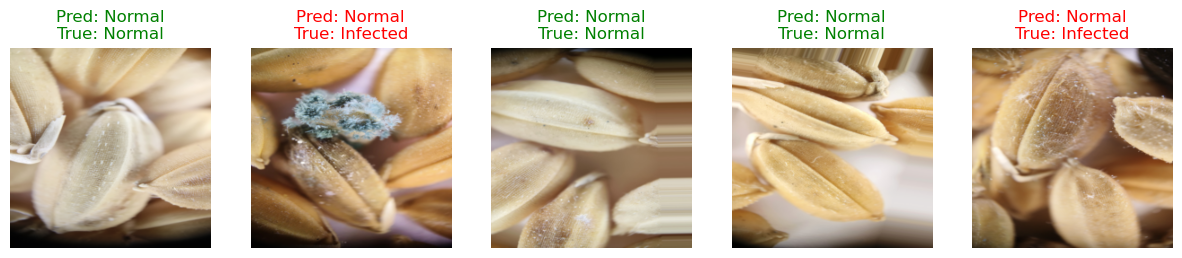

In [8]:
visualize_predictions(model, test_loader, num_images=5)


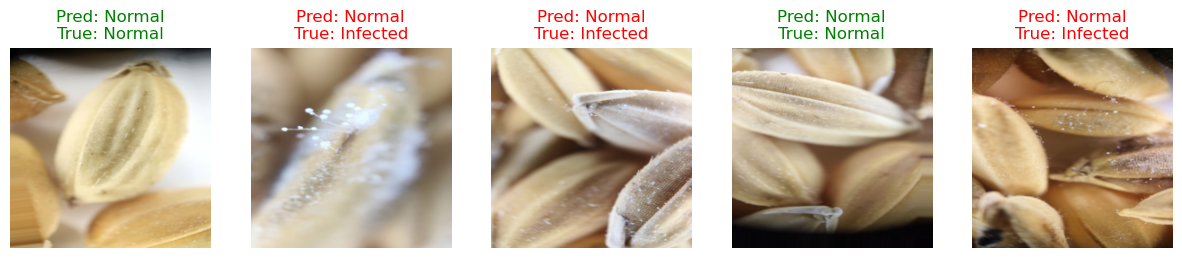

In [9]:
visualize_predictions(model, test_loader, num_images=5)


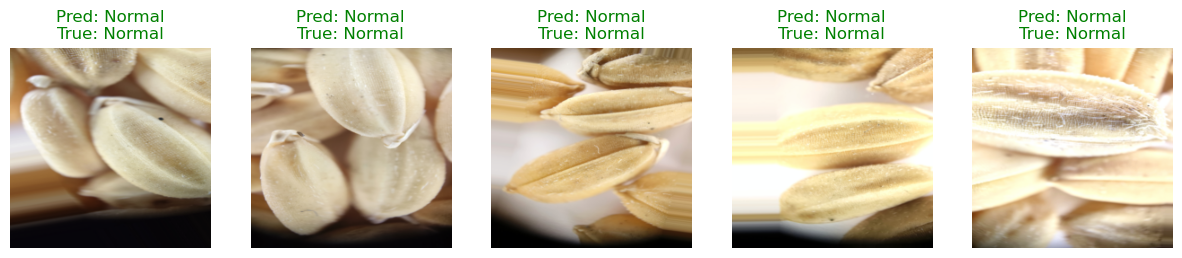

In [10]:
visualize_predictions(model, test_loader, num_images=5)


C:\Users\Srikanth\AppData\Roaming\Python\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Srikanth\AppData\Roaming\Python\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\Srikanth\AppData\Local\Temp\ipykernel_29672\3663749018.py:30: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See htt

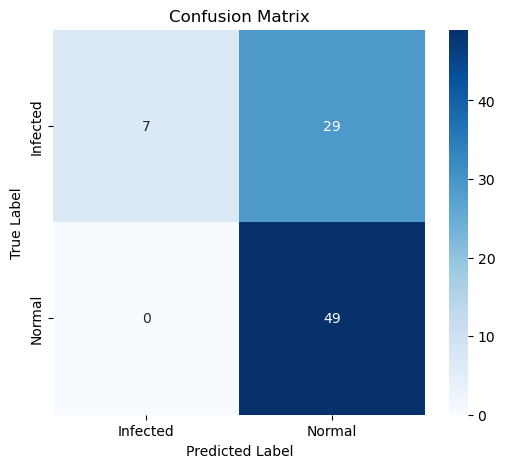


Classification Report:
              precision    recall  f1-score   support

    Infected       1.00      0.19      0.33        36
      Normal       0.63      1.00      0.77        49

    accuracy                           0.66        85
   macro avg       0.81      0.60      0.55        85
weighted avg       0.79      0.66      0.58        85



In [6]:
import torch
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torch.nn as nn
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from torchvision.models import resnet50
from sklearn.metrics import confusion_matrix, classification_report

# Step 1: Define Paths
test_data_resnet = "C:/Users/Srikanth/Desktop/DA Assignments/Desertation/Model/Dataset/dataset_resnet/test"

# Step 2: Define Transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Step 3: Load Test Dataset
test_dataset = datasets.ImageFolder(root=test_data_resnet, transform=transform)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1, shuffle=False)

# Step 4: Load Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = resnet50(pretrained=True)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)  # Binary Classification
model.load_state_dict(torch.load("resnet50_binary_classification.pth"))  # Load trained model
model = model.to(device)
model.eval()  # Set model to evaluation mode

# Step 5: Get Class Names
class_names = test_dataset.classes  # ['Normal', 'Infected']

# Step 6: Predict & Collect Results
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)  # Get predicted class index

        y_true.append(labels.cpu().numpy()[0])
        y_pred.append(preds.cpu().numpy()[0])

# Step 7: Compute Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Step 8: Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# Step 9: Print Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))
